# Week 5 — Part 02: Reproducibility Package Lab

**Estimated time:** 90–120 minutes

---

## Pre-study (Self-learn)

Self-learn is optional. If you want a refresher on environments, dependencies, and reproducibility:

- [Foundations Course Pre-study index](../PRESTUDY.md)
- [Self-learn — Chapter 2: Python and Environment Management](../self_learn/Chapters/2/Chapter2.md)

---

## What success looks like (end of Part 02)

- You save reproducible run artifacts under `artifacts/run_.../` that include:
  - `config.json` — the exact settings used
  - `metrics.json` — the results
  - `requirements.txt` — the dependencies
- Another person can recreate your environment and get similar results.

### Checkpoint

After running this notebook:
- You can point to `artifacts/run_.../config.json`
- You can point to `artifacts/run_.../requirements.txt`

## Learning Objectives

- Create a complete reproducibility package
- Capture configuration, metrics, and dependencies
- Understand what makes an experiment reproducible

**Lab tutorial**: [02_reproducibility_package.md](./02_reproducibility_package.md) - Detailed walkthrough and learning objectives

### What this part covers
This notebook focuses on **reproducibility** — the ability to re-run an experiment and get the same (or explainably similar) results.

A reproducibility package bundles together:
- **`config.json`** — exact parameters used (seed, model, hyperparameters)
- **`metrics.json`** — what happened (accuracy, F1, latency)
- **`requirements.txt`** — exact library versions

**Why this matters for LLM work:** When you later compare prompt strategies or model versions, reproducibility lets you isolate what changed. Was it the data? The prompt? The model version? Without saved configs and artifacts, you're guessing.

## Overview

This notebook explores **reproducibility packages** using our unified `ml_package`.

In this lab you will:

- explore the existing `ml_package` structure 
- use the package to create reproducible runs
- capture run inputs and metadata
- generate complete reproducibility packages

> **Note**: We now have a complete, production-ready `ml_package` that handles training, comparison, reporting, and reproducibility. This notebook will reference and use this package instead of creating duplicate code.

## Visual intuition: why the seed matters

A seed controls randomness. With the same seed, the validation split is repeatable. With a different seed, different rows may land in validation, and metrics can change even when the model code is identical.


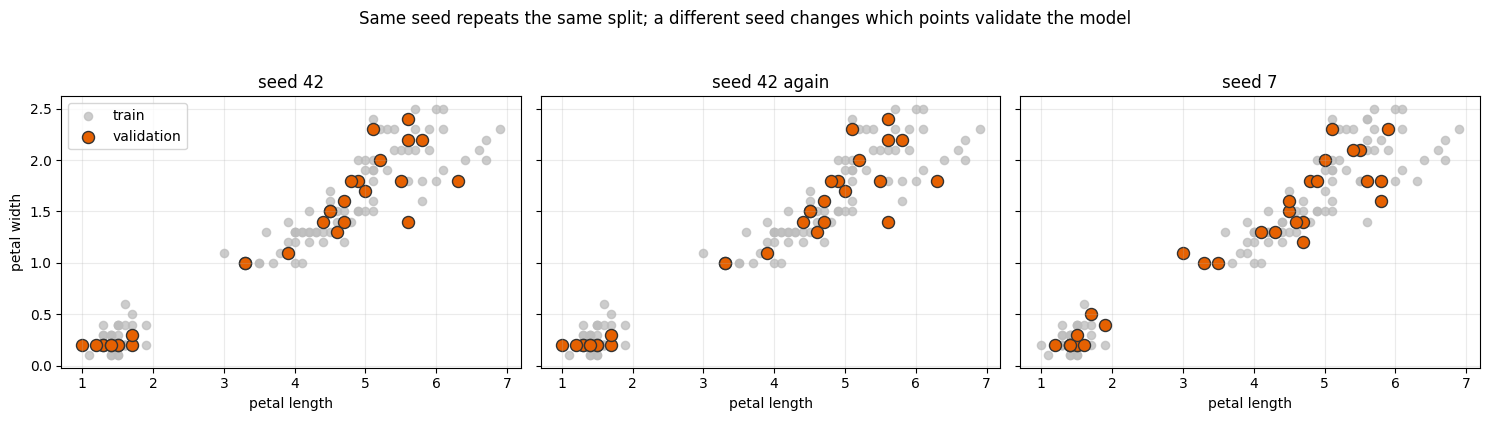

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
X_seed = iris.data[["petal length (cm)", "petal width (cm)"]]
y_seed = iris.target

split_specs = [(42, "seed 42"), (42, "seed 42 again"), (7, "seed 7")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (seed, title) in zip(axes, split_specs):
    X_train_seed, X_val_seed, y_train_seed, y_val_seed = train_test_split(
        X_seed, y_seed, test_size=0.2, random_state=seed, stratify=y_seed
    )
    ax.scatter(X_train_seed.iloc[:, 0], X_train_seed.iloc[:, 1], c="#bdbdbd", s=35, label="train", alpha=0.75)
    ax.scatter(X_val_seed.iloc[:, 0], X_val_seed.iloc[:, 1], c="#e66101", s=75, label="validation", edgecolor="#333333")
    ax.set_title(title)
    ax.set_xlabel("petal length")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("petal width")
axes[0].legend(loc="upper left")
fig.suptitle("Same seed repeats the same split; a different seed changes which points validate the model", y=1.04)
plt.tight_layout()
plt.show()


### What this cell does
Imports the `ml_package` modules and shows the package structure. The package is split into four focused modules:

- **`trainer.py`** — the 6-stage training pipeline (load → split → scale → train → evaluate → save)
- **`reproducibility.py`** — captures dependencies, validates the environment, creates run metadata
- **`comparison.py`** — loads multiple run folders, selects the best, summarizes across runs
- **`reporting.py`** — generates markdown reports and dashboards

**Why a package instead of one big script?** Each module has a single responsibility. You can test, reuse, and update each part independently. This is the same principle as pipeline stages in Week 6.

## Exercise 1: Explore the ML Package Structure

Let's examine our unified `ml_package` that handles all ML training needs:



In [12]:
from pathlib import Path

# Look at our package structure
package_root = Path("ml_package")
print("Package structure:")
for path in sorted(package_root.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(package_root)}")


Package structure:
  __init__.py
  comparison.py
  reporting.py
  reproducibility.py
  trainer.py




This package provides:
- **trainer.py** - Core training pipeline with 6 modular stages
- **comparison.py** - Run comparison and analysis utilities  
- **reporting.py** - Report generation and dashboards
- **reproducibility.py** - Dependency capture and environment validation



### What this cell does
Creates a sample dataset, configures a training run with explicit parameters, and runs `trainer.train()`.

**Key reproducibility habits shown here:**
- `random_state=42` — fixed seed so train/val splits are identical across runs
- `max_iter=500` — explicit hyperparameter, not a hidden default
- All parameters go into `TrainConfig` so they're automatically saved to `config.json`

**What to check:** After running, find the new timestamped folder under `artifacts/`. Open `config.json` — it should contain every parameter you set here.

In [13]:
# Explore the package structure
from pathlib import Path

package_root = Path("ml_package")
print("Package structure:")
for path in sorted(package_root.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(package_root)}")

# Import key components
from ml_package import trainer, reproducibility, comparison, reporting

print("\n✅ Successfully imported all package modules!")
print("Available functions:")
print("- trainer: train(), create_sample_dataset(), TrainConfig")
print("- reproducibility: capture_dependencies(), validate_environment()")
print("- comparison: load_runs(), select_best_run(), summarize_runs()")
print("- reporting: generate_experiment_summary(), write_comparison_report()")

Package structure:
  __init__.py
  comparison.py
  reporting.py
  reproducibility.py
  trainer.py

✅ Successfully imported all package modules!
Available functions:
- trainer: train(), create_sample_dataset(), TrainConfig
- reproducibility: capture_dependencies(), validate_environment()
- comparison: load_runs(), select_best_run(), summarize_runs()
- reporting: generate_experiment_summary(), write_comparison_report()


### What this cell does
Captures the full dependency environment (`requirements.txt`), validates that key packages are importable, and saves run metadata (config + environment info) to a JSON file.

**Why capture dependencies at run time?** Library versions change. If you re-run an experiment 3 months later with a newer `scikit-learn`, results may differ. Saving `requirements.txt` alongside your metrics means you can always recreate the exact environment that produced a result.

**What `validate_environment()` checks:** That each required package is importable and returns its version. This catches silent failures where a package is listed in `requirements.txt` but not actually installed correctly.

In [14]:
# Create sample data
sample_csv = "sample_iris.csv"
trainer.create_sample_dataset(sample_csv, "iris")

# Configure training
config = trainer.TrainConfig(
    input_csv=sample_csv,
    label_col="label", 
    test_size=0.2,
    random_state=42,
    max_iter=500
)

# Run training
result = trainer.train(config, "artifacts")
print(f"Training completed! Accuracy: {result.metrics['accuracy']:.4f}")
print(f"Artifacts saved to: {result.artifacts_dir}")

Training completed! Accuracy: 0.9667
Artifacts saved to: artifacts/run_20260605_182014


In [15]:
# Create a complete reproducibility package
from pathlib import Path

# Use the actual run directory returned by trainer.train().
run_dir = result.artifacts_dir

# Capture dependencies
reproducibility.capture_dependencies(run_dir / "requirements.txt")

# Validate environment
env_info = reproducibility.validate_environment(["pandas", "scikit-learn", "joblib", "numpy"])

# Create comprehensive metadata
metadata = reproducibility.create_run_metadata(
    config=config.__dict__,
    environment_info=env_info
)
reproducibility.save_run_metadata(metadata, run_dir / "run_metadata.json")

print(f"Reproducibility package created in: {run_dir}")
print("Files created:")
for file in run_dir.iterdir():
    print(f"  - {file.name}")

Reproducibility package created in: artifacts/run_20260605_182014
Files created:
  - metrics.json
  - model.joblib
  - val_report.txt
  - run_metadata.json
  - requirements.txt
  - config.json


## Exercise 3: Validate Reproducibility

Let's check if our run can be reproduced:



In [17]:
from pathlib import Path
# Check reproducibility score
repro_score = reproducibility.check_reproducibility(run_dir)
print(f"Reproducibility score: {repro_score['overall_score']}/100")

# Create a standalone reproducibility package
package_dir = Path("reproducibility_package")
reproducibility.create_reproducibility_package(run_dir, package_dir)

print(f"\nStandalone package created: {package_dir}")
print("This package can be shared and reproduced by others!")


Reproducibility score: 100/100



Standalone package created: reproducibility_package
This package can be shared and reproduced by others!


## Exercise 4: Compare Multiple Runs

Let's run multiple experiments and compare them:



In [18]:
# Run multiple experiments with different configurations
configs = [
    trainer.TrainConfig("sample_iris.csv", "label", 0.2, 42, 200),
    trainer.TrainConfig("sample_iris.csv", "label", 0.2, 42, 500),
    trainer.TrainConfig("sample_iris.csv", "label", 0.3, 42, 500),
]

results = []
for i, cfg in enumerate(configs):
    result = trainer.train(cfg, "artifacts")
    results.append(result)
    print(f"Run {i+1}: accuracy={result.metrics['accuracy']:.4f}, max_iter={cfg.max_iter}")

# Load and compare all runs
runs = comparison.load_runs("artifacts")
summary = comparison.summarize_runs(runs)
best = comparison.select_best_run(runs, "accuracy")

print(f"\nBest run: {best.run_id} with accuracy {best.metrics['accuracy']:.4f}")
print(f"Average accuracy across {len(runs)} runs: {summary['avg_accuracy']:.4f}")

Run 1: accuracy=0.9667, max_iter=200
Run 2: accuracy=0.9667, max_iter=500
Run 3: accuracy=0.9333, max_iter=500

Best run: run_20260605_182014 with accuracy 0.9667
Average accuracy across 2 runs: 0.9500


## Exercise 5: Generate Reports

Let's create comprehensive reports for our experiments:



In [ ]:
# Generate experiment reports from the comparison runs
from pathlib import Path

output_dir = Path("reports")
output_dir.mkdir(exist_ok=True)

# Generate a full experiment summary (comparison_report.md, summary.json, runs.json)
reporting.generate_experiment_summary(runs, output_dir)

print("Generated reports:")
for f in sorted(output_dir.iterdir()):
    print(f"  {f.name}")

# Show the comparison report content
report_path = output_dir / "comparison_report.md"
if report_path.exists():
    print(f"\n--- {report_path.name} ---")
    print(report_path.read_text(encoding="utf-8")[:500])

Generated reports:
  comparison_report.md
  runs.json
  summary.json

--- comparison_report.md ---
# ML Experiment Comparison Report

**Total runs analyzed:** 2

## Summary Statistics

- **Average f1_macro:** 0.9499
- **Average train_seconds:** 0.0155
- **Average n_val:** 37.5
- **Average accuracy:** 0.95
- **Average n_train:** 112.5
- **Best f1_macro:** 0.9665831244778612 (run: run_20260605_182014)
- **Best train_seconds:** 0.01680188626050949 (run: run_20260605_182015)
- **Best n_val:** 45 (run: run_20260605_182015)
- **Best accuracy:** 0.9666666666666667 (run: run_20260605_182014)
- **Best


## Self-check

✅ **Reproducibility Achieved:**
- Complete package structure with modular components
- Deterministic seeds stored with artifacts  
- Dependency capture and environment validation
- Run comparison and reporting capabilities

✅ **Package Features:**
- **trainer.py**: 6-stage modular training pipeline
- **comparison.py**: Load, compare, and analyze multiple runs
- **reporting.py**: Generate markdown reports and dashboards
- **reproducibility.py**: Capture dependencies and validate environments

✅ **CLI Tools Available:**
- `python train.py` - Run training with reproducibility
- `python compare_runs.py` - Compare and analyze experiments

The package eliminates code duplication while providing enhanced functionality for reproducible ML experiments!